In [1]:
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


#df = pd.read_csv("C:\\Users\\lclai\\Desktop\\LDIG\\research LDIG\\data_dementia\\clean\\pitt_clean.csv")

df = pd.read_csv(r"C:\Users\lclai\OneDrive - LDIG\wesharecare\data_dementia\clean\pitt_clean.csv")

df = df[df["label"].isin([0, 1])]
df["sex"] = df["sex"].map({"M": 0, "F": 1})
df.dropna(subset=["clean_transcripts", "age", "sex"], inplace=True)
clean_text = df["clean_transcripts"].apply(lambda x: x.split())

In [2]:
df.head(5)

,subject,age,sex,label,transcript,clean_transcripts
0,0,58,1,0,PAR: the scene is <in the> [/] in the kitchen ...,the scene is in the in the kitchen . the mothe...
1,1,59,1,0,INV: what do you see going on in that picture ...,oh I see the sink is running over . I see the ...
2,2,60,1,0,INV: look at the picture and tell me everythin...,um a boy and a girl are in the kitchen with th...
3,3,61,1,0,INV: look at that picture and I want you to te...,okay . it was summertime and mother and the ch...
4,4,72,0,0,PAR: &=clears:throat wait (un)til I put my gla...,clearsthroat wait until I put my glasses on . ...


### INFLUENCE OF AGE IN THE MODEL

In [3]:
mean_age_by_label = df.groupby('label')['age'].mean()
print(mean_age_by_label)

label
0    64.888889
1    71.794466
Name: age, dtype: float64


In [4]:
from scipy.stats import ttest_ind

age_healthy = df[df['label'] == 0]['age']
age_dementia = df[df['label'] == 1]['age']

t_stat, p_value = ttest_ind(age_healthy, age_dementia, equal_var=False) 
print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -9.540779287616315
p-value: 6.54912748436393e-20


In [7]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def remove_inv_phrases(text):
    if isinstance(text, str):
        sentences = [s.strip() for s in text.split('.') if s.strip()]
        cleaned = [s for s in sentences if not s.startswith("INV")]
        return '. '.join(cleaned) + ('.' if cleaned else '')

df["clean_transcripts"] = df["clean_transcripts"].apply(remove_inv_phrases)

sex = df[["sex"]]
age = df[["age"]]
texts = df["clean_transcripts"].to_numpy()

y = LabelEncoder().fit_transform(df["label"])

X_raw = np.hstack((sex, age))  

X_raw_train, X_raw_test, texts_train, texts_test, y_train, y_test = train_test_split(
    X_raw, texts, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=300)
X_text_train = vectorizer.fit_transform(texts_train).toarray()
X_text_test = vectorizer.transform(texts_test).toarray()

X_train = np.hstack((X_raw_train, X_text_train))
X_test = np.hstack((X_raw_test, X_text_test))

X_train = pd.DataFrame(X_train, columns=['sex']+ [f"feature_{i}" for i in range(X_train.shape[1] - 1)])
X_test = pd.DataFrame(X_test, columns=['sex']+ [f"feature_{i}" for i in range(X_test.shape[1] - 1)])
X_test

,sex,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_291,feature_292,feature_293,feature_294,feature_295,feature_296,feature_297,feature_298,feature_299,feature_300
0,1.0,69.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1,1.0,77.0,0.000000,0.533123,0.087120,0.0,0.0,0.172841,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
2,0.0,73.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
3,1.0,87.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
4,0.0,63.0,0.154005,0.205261,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,72.0,0.062659,0.250539,0.109178,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.070944,0.0,0.000000,0.000000,0.0,0.0,0.060638,0.000000
96,0.0,79.0,0.000000,0.000000,0.121520,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.090405,0.0,0.0,0.269972,0.000000
97,1.0,84.0,0.093534,0.000000,0.081488,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.090518,0.000000
98,0.0,73.0,0.071394,0.285465,0.124397,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.080833,0.0,0.127459,0.000000,0.0,0.0,0.069091,0.000000


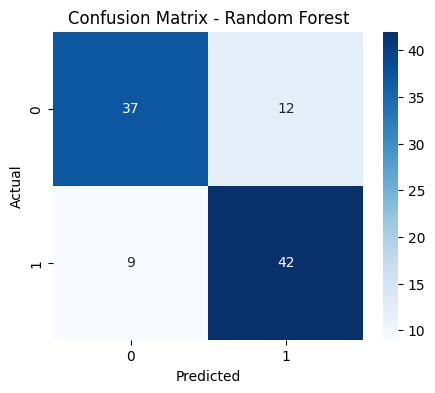

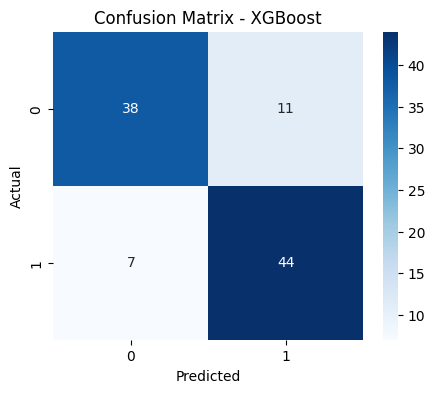

Model: Random Forest
Best Params: {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 1000}
Mean AUC (CV=5): 0.9180
STD AUC (CV=5): 0.0266
AUC on Test Set: 0.8960

Model: XGBoost
Best Params: {'model__learning_rate': 0.01, 'model__max_depth': 6, 'model__n_estimators': 1000, 'model__subsample': 0.8}
Mean AUC (CV=5): 0.8838
STD AUC (CV=5): 0.0465
AUC on Test Set: 0.9156



In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

non_scaled_columns = ['sex']  # no escalar
scaled_columns = [col for col in X_train.columns if col not in non_scaled_columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaled_columns)
    ],
    remainder='passthrough'  
)

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

param_grids = {
    'Random Forest': {
        'model__n_estimators': [500, 1000],
        'model__max_depth': [None, 2,10],
        'model__min_samples_split': [2,5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'model__n_estimators': [500, 1000],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 6, 10],
        'model__subsample': [0.8, 1.0]
    }
}

results = {}

for model_name in models:
    model = models[model_name]
    param_grid = param_grids[model_name]

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    mean_auc_cv = grid_search.best_score_
    std_auc_cv = grid_search.cv_results_['std_test_score'][grid_search.best_index_]

    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    auc_test = roc_auc_score(y_test, y_pred_proba)

    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results[model_name] = {
        'best_params': grid_search.best_params_,
        'mean_auc_cv': mean_auc_cv,
        'std_cv': std_auc_cv,
        'auc_test': auc_test,
        'best_model': best_model
    }

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"Best Params: {result['best_params']}")
    print(f"Mean AUC (CV=5): {result['mean_auc_cv']:.4f}")
    print(f"STD AUC (CV=5): {result['std_cv']:.4f}")
    print(f"AUC on Test Set: {result['auc_test']:.4f}\n")